In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset from Task 1
df_eda = pd.read_csv("cleaned_stock_prices.csv")

# Convert date back to datetime after loading from CSV
df_eda["date"] = pd.to_datetime(df_eda["date"])

# Display first 5 rows
df_eda.head()

,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


In [2]:
# Check rows, columns, and data types
df_eda.info()

# Check dataset size
df_eda.shape

# Check missing values
df_eda.isnull().sum()

# Check duplicates
df_eda.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  str           
 1   date    497472 non-null  datetime64[us]
 2   open    497472 non-null  float64       
 3   high    497472 non-null  float64       
 4   low     497472 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 26.6 MB


np.int64(0)

In [3]:
# Summary statistics for numerical columns
df_eda.describe()

,date,open,high,low,close,volume
count,497472,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,2016-01-06 17:16:00.439984,86.352811,87.133240,85.553126,86.369082,4.253611e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.472255,102.313335,100.572155,101.472407,8.232139e+06


In [4]:
# Select numerical columns
numeric_cols = ["open", "high", "low", "close", "volume"]

# Calculate required summary statistics
summary_stats = pd.DataFrame({
    "mean": df_eda[numeric_cols].mean(),
    "median": df_eda[numeric_cols].median(),
    "mode": df_eda[numeric_cols].mode().iloc[0],
    "standard_deviation": df_eda[numeric_cols].std()
})

summary_stats

,mean,median,mode,standard_deviation
open,8.635281e+01,6.497000e+01,70.0,1.014723e+02
high,8.713324e+01,6.556000e+01,72.0,1.023133e+02
low,8.555313e+01,6.435370e+01,77.0,1.005722e+02
close,8.636908e+01,6.498000e+01,34.5,1.014724e+02
volume,4.253611e+06,2.084896e+06,1241019.0,8.232139e+06


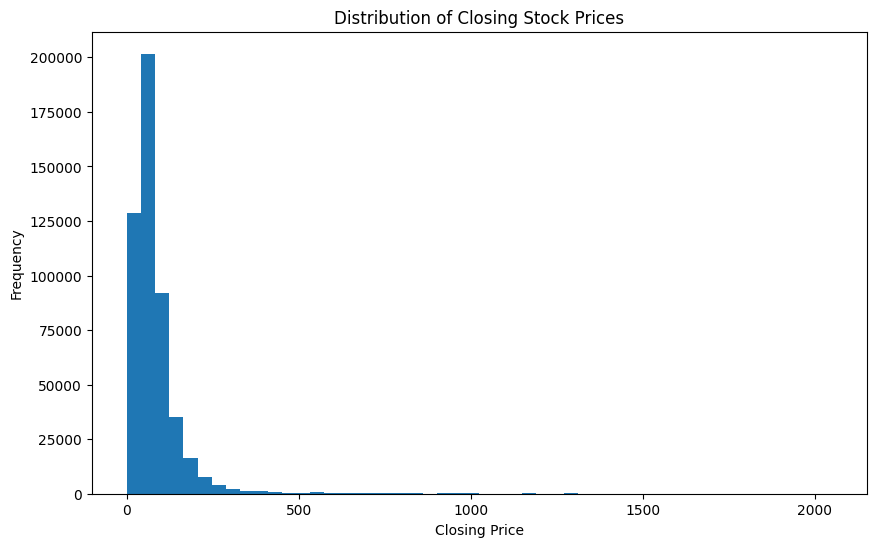

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df_eda["close"], bins=50)
plt.title("Distribution of Closing Stock Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

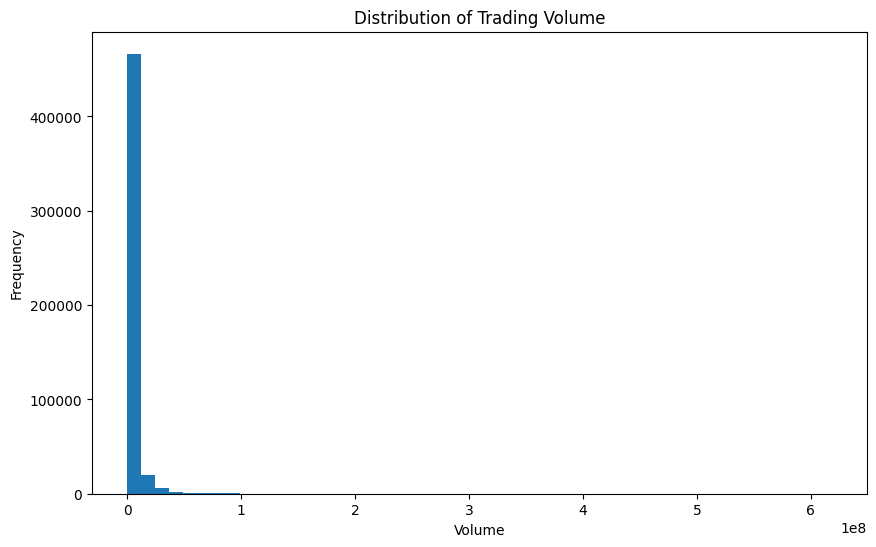

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df_eda["volume"], bins=50)
plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

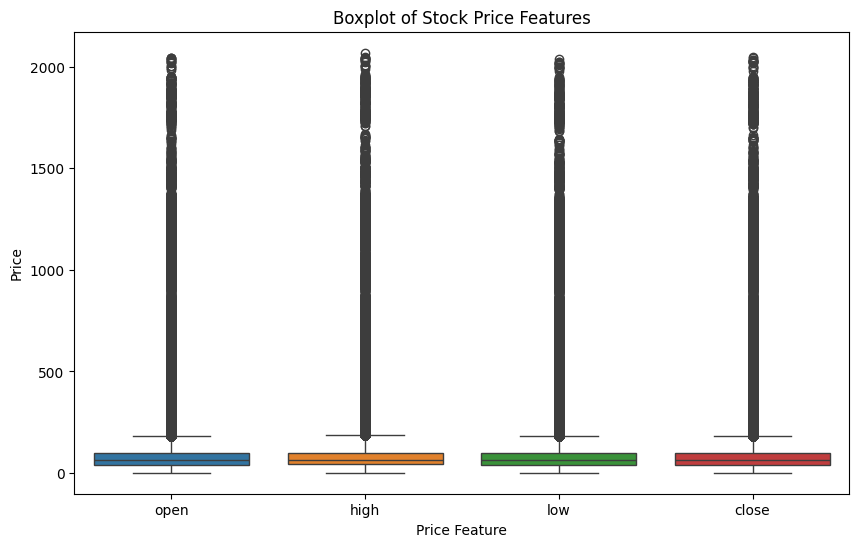

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda[["open", "high", "low", "close"]])
plt.title("Boxplot of Stock Price Features")
plt.xlabel("Price Feature")
plt.ylabel("Price")
plt.show()

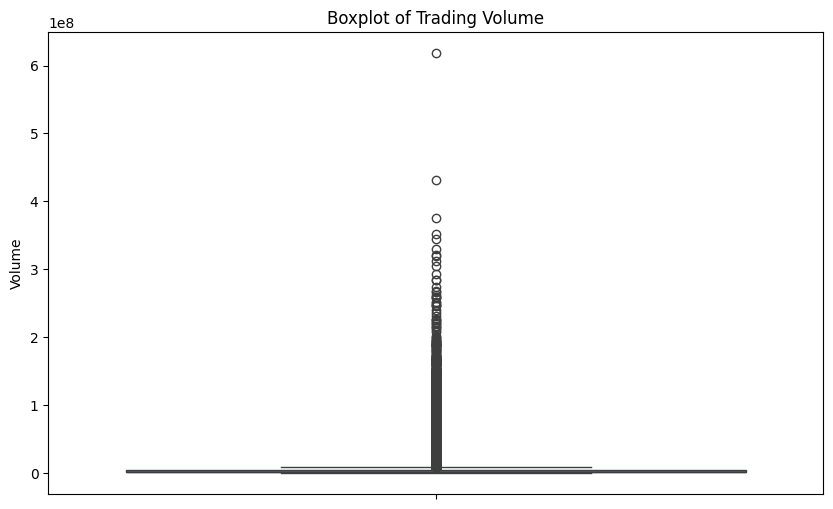

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_eda["volume"])
plt.title("Boxplot of Trading Volume")
plt.ylabel("Volume")
plt.show()

In [9]:
# Create a sample for clearer scatter plots
df_sample = df_eda.sample(n=5000, random_state=42)

df_sample.head()

,symbol,date,open,high,low,close,volume
367414,PM,2016-07-27,98.980,99.0000,97.14,97.330,7059022
86606,CCL,2016-12-22,52.990,53.1614,52.08,52.410,2693191
246299,IR,2017-08-21,85.090,85.3400,84.76,85.130,830531
229761,HSIC,2015-06-25,72.285,72.4650,71.99,72.245,676964
247249,IRM,2017-05-31,35.160,35.3100,34.83,34.920,1590800


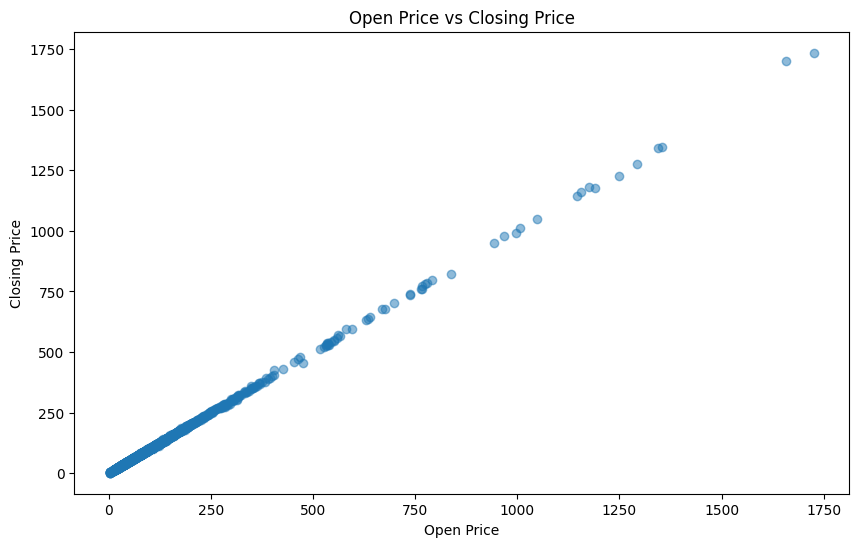

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df_sample["open"], df_sample["close"], alpha=0.5)
plt.title("Open Price vs Closing Price")
plt.xlabel("Open Price")
plt.ylabel("Closing Price")
plt.show()

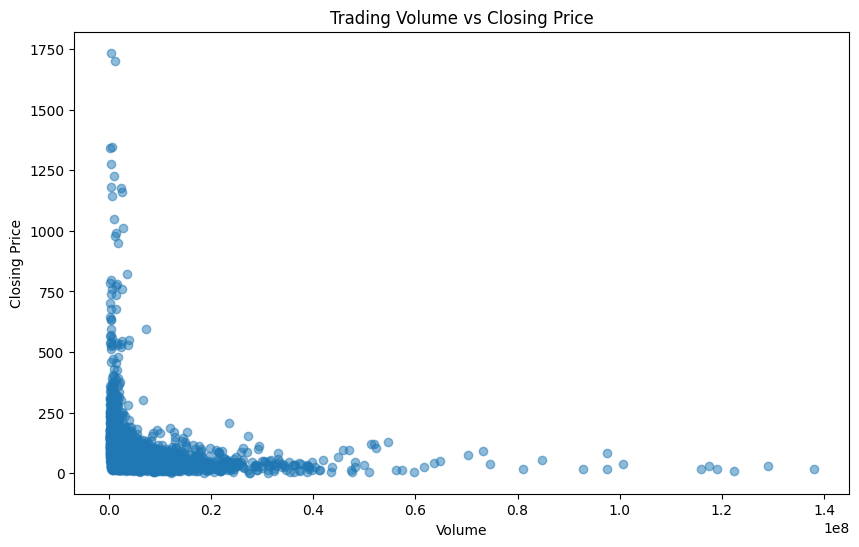

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_sample["volume"], df_sample["close"], alpha=0.5)
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Volume")
plt.ylabel("Closing Price")
plt.show()

In [12]:
correlation_matrix = df_eda[numeric_cols].corr()

correlation_matrix

,open,high,low,close,volume
open,1.000000,0.999941,0.999928,0.999876,-0.148724
high,0.999941,1.000000,0.999905,0.999938,-0.148344
low,0.999928,0.999905,1.000000,0.999941,-0.149284
close,0.999876,0.999938,0.999941,1.000000,-0.148839
volume,-0.148724,-0.148344,-0.149284,-0.148839,1.000000


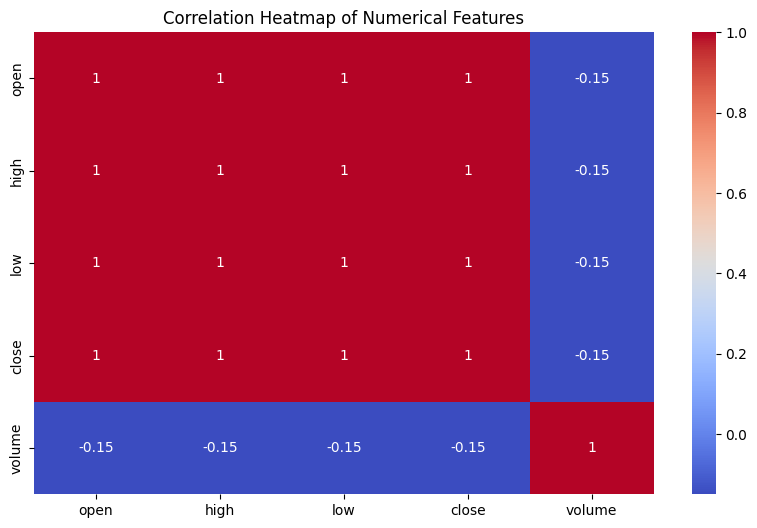

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

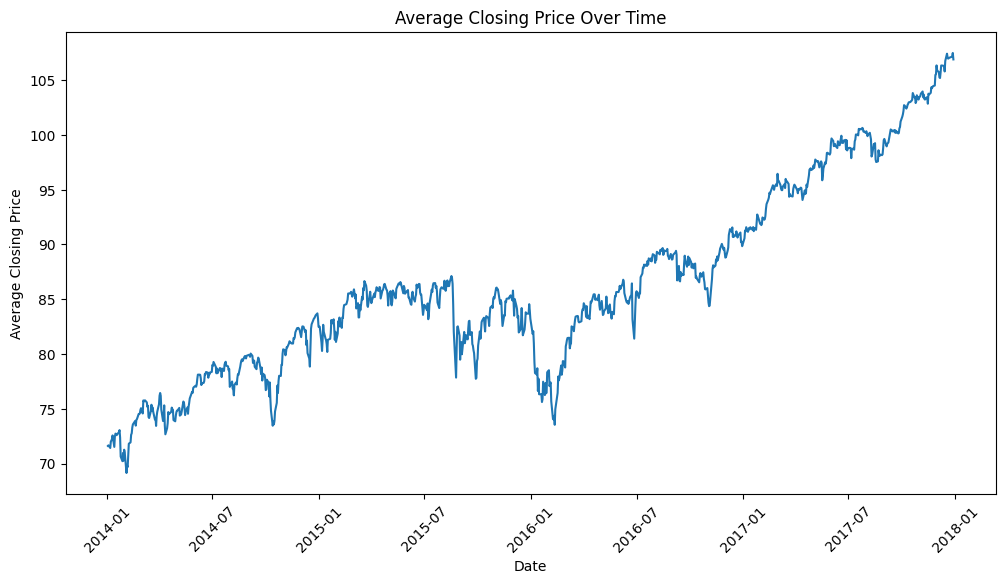

In [14]:
# Calculate average closing price per date
daily_average_close = df_eda.groupby("date")["close"].mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_average_close.index, daily_average_close.values)
plt.title("Average Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.show()

## Task 2: Exploratory Data Analysis Summary

The cleaned stock prices dataset was used for exploratory data analysis. The dataset contained 497,472 rows and 7 columns. Before analysis, I confirmed that there were no missing values or duplicate rows.

Summary statistics were calculated for the numerical columns: `open`, `high`, `low`, `close`, and `volume`. The mean, median, mode, and standard deviation were used to understand the central tendency and spread of the data.

Histograms were created to show the distributions of closing prices and trading volume. Boxplots were used to identify the spread of stock price variables and possible outliers. Scatter plots were created to examine the relationships between opening price and closing price, as well as trading volume and closing price.

A correlation matrix and heatmap were used to identify relationships between numerical variables. The strongest correlations were found between `open`, `high`, `low`, and `close`, which is expected because these variables all represent stock prices from the same trading day. Trading volume had a weaker relationship with the price variables.

Overall, the exploratory analysis showed that stock price variables are strongly related to each other, while trading volume behaves differently and may require separate analysis.